In [3]:
#imports

import pandas as pd
import numpy as np
import os

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

In [10]:
path_A = r"C:\Users\chand\OneDrive\Documents\Sepsis Project\data\training_setA\training_setA"

path_B = r"C:\Users\chand\OneDrive\Documents\Sepsis Project\data\training_setB\training_setB"

In [11]:
#Data function
def load_dataset(folder_path):

    all_data = []

    for file in os.listdir(folder_path):

        if file.endswith(".psv"):

            filepath = os.path.join(folder_path, file)

            temp_df = pd.read_csv(
                filepath,
                sep='|'
            )

            temp_df["PatientID"] = file

            all_data.append(temp_df)

    return pd.concat(
        all_data,
        ignore_index=True
    )

In [12]:
df_A = load_dataset(path_A)
df_B = load_dataset(path_B)

df = pd.concat(
    [df_A, df_B],
    ignore_index=True
)
print(df.shape)

(1552210, 42)


In [13]:
#dataset info
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1552210 entries, 0 to 1552209
Data columns (total 42 columns):
 #   Column            Non-Null Count    Dtype  
---  ------            --------------    -----  
 0   HR                1398811 non-null  float64
 1   O2Sat             1349474 non-null  float64
 2   Temp              525226 non-null   float64
 3   SBP               1325945 non-null  float64
 4   MAP               1358940 non-null  float64
 5   DBP               1065656 non-null  float64
 6   Resp              1313875 non-null  float64
 7   EtCO2             57636 non-null    float64
 8   BaseExcess        84145 non-null    float64
 9   HCO3              65028 non-null    float64
 10  FiO2              129365 non-null   float64
 11  pH                107573 non-null   float64
 12  PaCO2             86301 non-null    float64
 13  SaO2              53561 non-null    float64
 14  AST               25183 non-null    float64
 15  BUN               106568 non-null   float64
 16  

In [14]:
#sepsis distribution
df["SepsisLabel"].value_counts()

SepsisLabel
0    1524294
1      27916
Name: count, dtype: int64

In [15]:
#missing values
missing = (
    df.isnull()
      .mean()
      .sort_values(ascending=False)
      * 100
)

missing.head(20)

Bilirubin_direct    99.807371
Fibrinogen          99.340167
TroponinI           99.047745
Bilirubin_total     98.509158
Alkalinephos        98.393194
AST                 98.377604
Lactate             97.329872
PTT                 97.055875
SaO2                96.549372
EtCO2               96.286843
Phosphate           95.986303
HCO3                95.810618
Chloride            95.460279
BaseExcess          94.579020
PaCO2               94.440121
Calcium             94.116067
Platelets           94.059502
Creatinine          93.904433
Magnesium           93.689578
WBC                 93.593199
dtype: float64

In [16]:
#Drop Highly Missing Columns
cols_keep = df.columns[
    df.isnull().mean() < 0.70
]

df = df[cols_keep]

print(df.shape)

(1552210, 15)


In [18]:
#Fill Missing Values
num_cols = df.select_dtypes(
    include=np.number
).columns

imputer = SimpleImputer(
    strategy="median"
)

df[num_cols] = imputer.fit_transform(
    df[num_cols]
)

print("Missing values handled")

#verification
df.isnull().sum().sum()

Missing values handled


np.int64(0)

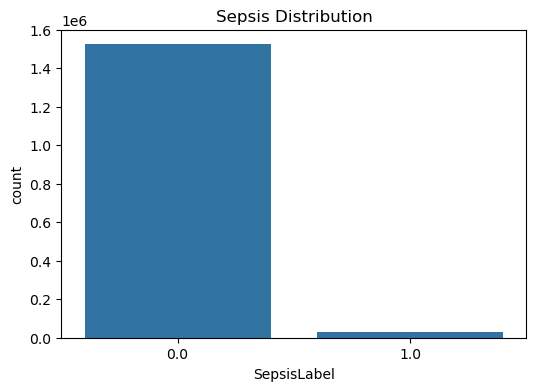

In [19]:
#Sepsis Count Plot
plt.figure(figsize=(6,4))

sns.countplot(
    x="SepsisLabel",
    data=df
)

plt.title("Sepsis Distribution")

plt.show()

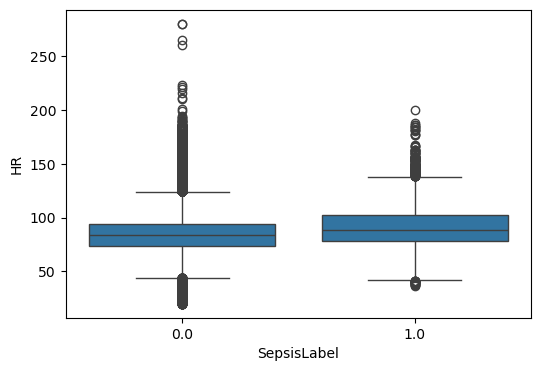

In [20]:
#Hear rate analysis
plt.figure(figsize=(6,4))

sns.boxplot(
    x="SepsisLabel",
    y="HR",
    data=df
)

plt.show()

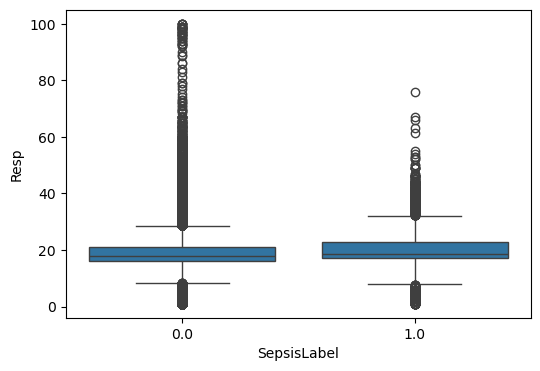

In [21]:
#Respiratory rate
plt.figure(figsize=(6,4))

sns.boxplot(
    x="SepsisLabel",
    y="Resp",
    data=df
)

plt.show()

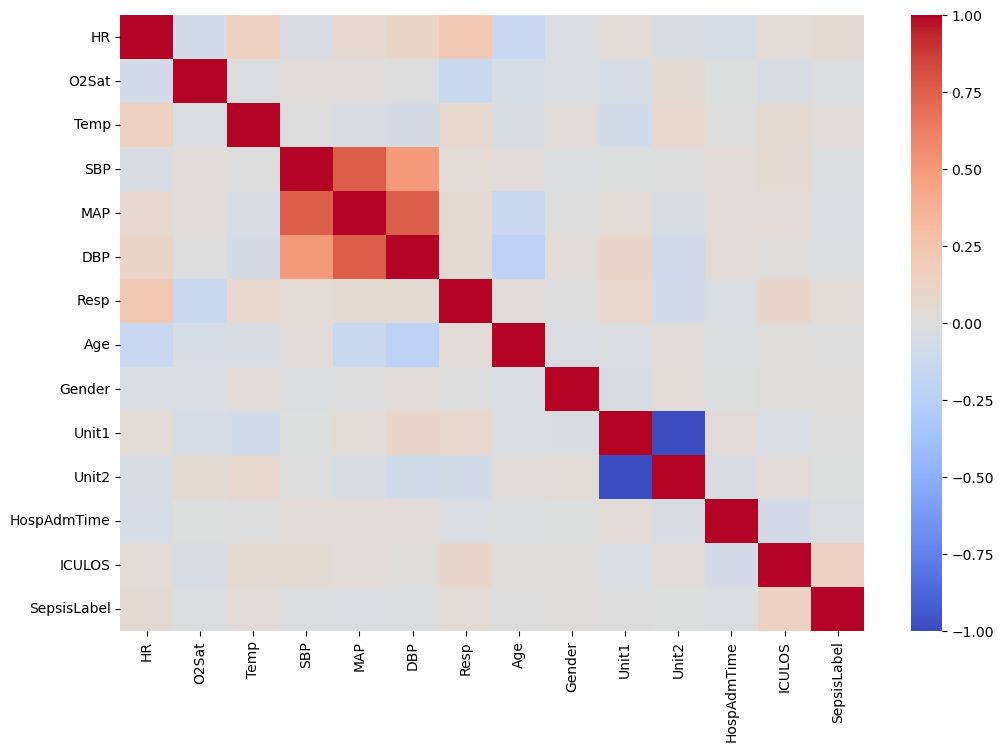

In [22]:
#correlation heatmap
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    cmap="coolwarm"
)

plt.show()

In [23]:
#feature selection
X = df.drop(
    ["SepsisLabel", "PatientID"],
    axis=1
)

y = df["SepsisLabel"]

In [25]:
#data split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [26]:
#model training
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(
    X_train,
    y_train
)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [27]:
#predictions
pred = model.predict(X_test)

prob = model.predict_proba(X_test)[:,1]

In [28]:
#evaluation metrics
print(
    classification_report(
        y_test,
        pred
    )
)

              precision    recall  f1-score   support

         0.0       0.98      1.00      0.99    304864
         1.0       0.91      0.08      0.15      5578

    accuracy                           0.98    310442
   macro avg       0.94      0.54      0.57    310442
weighted avg       0.98      0.98      0.98    310442



In [29]:
print(
    roc_auc_score(
        y_test,
        prob
    )
)

0.9444528619439918


In [30]:
#feature importance
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(15)

,Feature,Importance
7,Age,0.162896
12,ICULOS,0.146268
11,HospAdmTime,0.132045
0,HR,0.092439
3,SBP,0.092040
4,MAP,0.085793
6,Resp,0.072798
5,DBP,0.071506
1,O2Sat,0.057740
2,Temp,0.052877


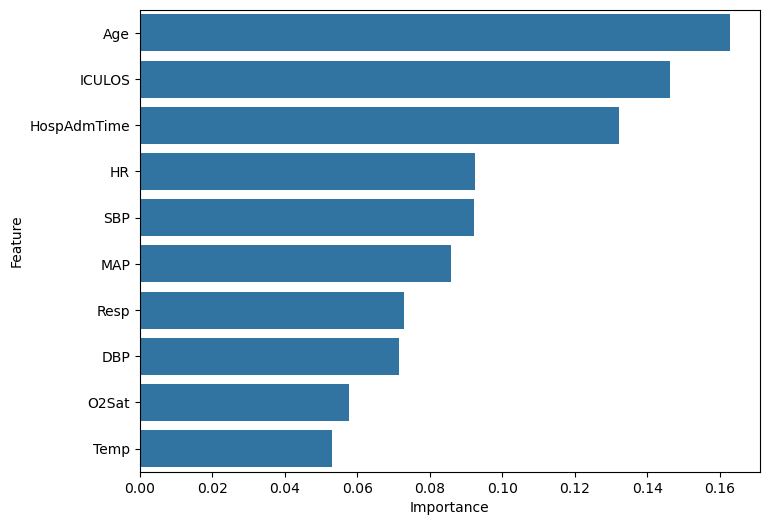

In [31]:
plt.figure(figsize=(8,6))

sns.barplot(
    data=importance.head(10),
    x="Importance",
    y="Feature"
)

plt.show()

In [32]:
#risk score
df["RiskScore"] = (
    model.predict_proba(X)[:,1]
    * 100
)

In [34]:
#risk level
df["RiskLevel"] = pd.cut(
    df["RiskScore"],
    bins=[-1,30,70,100],
    labels=["Low","Medium","High"]
)

df[["RiskScore","RiskLevel"]].head()

,RiskScore,RiskLevel
0,0.0,Low
1,0.0,Low
2,2.0,Low
3,1.0,Low
4,0.0,Low


In [35]:
#save processed data
df.to_csv(
    "sepsis_dashboard.csv",
    index=False
)

print("Export Complete")

Export Complete


In [36]:
df.to_csv(
    r"C:\Users\chand\OneDrive\Documents\Sepsis Project\data\sepsis_dashboard.csv",
    index=False
)